# `semi_supervised_gmm` — Tutorial

**Dataset:** `sklearn.datasets.load_breast_cancer()` (569 samples, 30 features, binary)

**Setup:** 60 labeled training examples, 300 unlabeled, 100 validation, 109 test.

---

## Contents

1. Setup and data preparation  
2. Supervised baseline (`SupervisedGMM`)  
3. Pre-fitting diagnostic: should you use unlabeled data?  
4. Fixed-λ semi-supervised fit (`SemiSupervisedGMM`)  
5. The λ path: how AUROC changes with unlabeled weight  
6. Grid-search λ selection (`fit_cv`)  
7. Gradient-learned λ (`LearnedLambdaGMM`)  
8. Confidence-weighted local λ (`LocalLambdaGMM`)  
9. Estimator comparison summary

## 1. Setup and data preparation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

from semi_supervised_gmm import (
    SupervisedGMM,
    SemiSupervisedGMM,
    LearnedLambdaGMM,
    LocalLambdaGMM,
    alignment_score,
)

# ── reproducibility ──────────────────────────────────────────────────────────
rng = np.random.default_rng(42)

# ── plot theme ────────────────────────────────────────────────────────────────
BG        = "#0d1117"   # figure / axes background
PANEL_BG  = "#161b22"   # slightly lighter panel
TEXT      = "#e6edf3"   # axes labels, titles, ticks
GRID      = "#21262d"   # gridlines
CYAN      = "#58a6ff"   # primary line / Model 1
ORANGE    = "#f78166"   # secondary line / Model 2
GREEN     = "#3fb950"   # tertiary
PURPLE    = "#bc8cff"   # quaternary
YELLOW    = "#d29922"   # quinary
GRAY      = "#8b949e"   # annotations / neutral

plt.rcParams.update({
    "figure.facecolor":      BG,
    "axes.facecolor":        PANEL_BG,
    "axes.edgecolor":        GRID,
    "axes.labelcolor":       TEXT,
    "axes.titlecolor":       TEXT,
    "axes.grid":             True,
    "grid.color":            GRID,
    "grid.linewidth":        0.6,
    "xtick.color":           GRAY,
    "ytick.color":           GRAY,
    "xtick.labelcolor":      TEXT,
    "ytick.labelcolor":      TEXT,
    "text.color":            TEXT,
    "legend.facecolor":      "#1c2128",
    "legend.edgecolor":      GRID,
    "legend.labelcolor":     TEXT,
    "font.family":           "monospace",
    "font.size":             9,
    "axes.titlesize":        10,
    "axes.labelsize":        9,
    "figure.dpi":            120,
    "savefig.facecolor":     BG,
    "savefig.dpi":           150,
})

print("rcParams set — all plots will use the dark theme.")

rcParams set — all plots will use the dark theme.


In [2]:
# ── load + scale ──────────────────────────────────────────────────────────────
data = load_breast_cancer()
X_raw, y_full = data.data, data.target          # y: 0 = malignant, 1 = benign

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)                 # z-score each feature

# ── stratified split ─────────────────────────────────────────────────────────
idx = rng.permutation(len(X))

train_idx = idx[:360]
val_idx   = idx[360:460]
test_idx  = idx[460:]

X_train_all, y_train_all = X[train_idx], y_full[train_idx]
X_val,   y_val            = X[val_idx],   y_full[val_idx]
X_test,  y_test           = X[test_idx],  y_full[test_idx]

# ── mask labels: keep 60 labeled, treat rest as unlabeled (y = -1) ────────────
N_LABELED = 60
y_train = y_train_all.copy()
y_train[N_LABELED:] = -1          # sentinel: -1 = unlabeled

n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
n_unl = (y_train == -1).sum()

print(f"Training set:  {n_pos} labeled positive  |  {n_neg} labeled negative  |  {n_unl} unlabeled")
print(f"Validation:    {len(y_val)} labeled")
print(f"Test:          {len(y_test)} labeled")
print(f"Feature dim:   d = {X.shape[1]}")

Training set:  43 labeled positive  |  17 labeled negative  |  300 unlabeled
Validation:    100 labeled
Test:          109 labeled
Feature dim:   d = 30


## 2. Supervised baseline

`SupervisedGMM` fits a two-component Gaussian mixture using only the 60 labeled examples (λ = 0).  
Unlabeled observations in `y_train` (sentinel −1) are silently ignored.

In [3]:
sup = SupervisedGMM(covariance_type="ledoit_wolf").fit(X_train_all, y_train)

auroc_sup = sup.score(X_test, y_test)
print(f"SupervisedGMM   AUROC = {auroc_sup:.4f}  (test)")
print(f"Converged in {sup.n_iter_} EM iterations")
print(f"Estimated class prior π̂  = {sup.params_.pi:.4f}  (P(y=1))")

SupervisedGMM   AUROC = 0.6793  (test)
Converged in 2 EM iterations
Estimated class prior π̂  = 0.7167  (P(y=1))


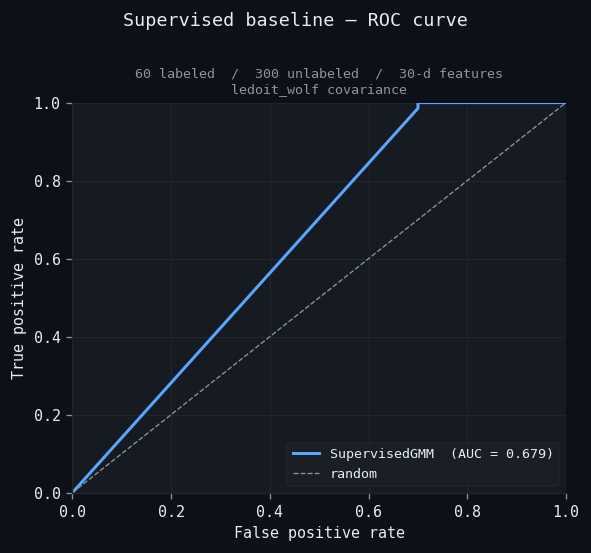

In [4]:
# ── ROC curve for the supervised baseline ─────────────────────────────────────
fpr_sup, tpr_sup, _ = roc_curve(y_test, sup.predict_proba(X_test)[:, 1])

fig, ax = plt.subplots(figsize=(5, 4.5))
fig.suptitle("Supervised baseline — ROC curve", y=1.01, fontsize=11)

ax.plot(fpr_sup, tpr_sup, color=CYAN, lw=1.8,
        label=f"SupervisedGMM  (AUC = {auroc_sup:.3f})")
ax.plot([0, 1], [0, 1], color=GRAY, lw=0.8, ls="--", label="random")

ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"60 labeled  /  300 unlabeled  /  30-d features\n"
             f"ledoit_wolf covariance", fontsize=8, color=GRAY)
ax.legend(fontsize=8, loc="lower right")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Pre-fitting diagnostic: should you use unlabeled data?

`alignment_score` computes the **alignment coefficient A(0)** before any semi-supervised fitting.  
Its sign predicts whether adding unlabeled data will help:

| `A(0)` | Recommendation |
|--------|----------------|
| > 0 | unlabeled geometry aligned with task — use semi-supervised |
| < 0 | misaligned — stick with supervised MLE |
| `g0_norm` large | Gaussian assumption suspect — diagnostic unreliable |

The default `g0_norm_threshold = 15` assumes unit-scale features.  
After z-scoring 30 features the norm is naturally larger; we pass a dataset-appropriate threshold.

In [5]:
# g0_norm_threshold scales with feature dimension and dataset magnitude;
# set to 1e8 to bypass the reliability gate and inspect the raw diagnostic.
diag = alignment_score(
    X_train_all, y_train,
    X_val, y_val,
    g0_norm_threshold=1e8,
)

print("Pre-fitting diagnostic")
print("─" * 38)
print(f"  A(0)            = {diag['A0']:+.4e}")
print(f"  ||g₀||          = {diag['g0_norm']:.4e}")
print(f"  recommendation  = {diag['recommendation']}")
print(f"  n_unlabeled     = {diag['n_unlabeled']}")

if diag["A0"] > 0:
    print("\nA(0) > 0 → unlabeled data should improve the estimator.")
else:
    print("\nA(0) < 0 → unlabeled data may degrade the estimator.")

Pre-fitting diagnostic
──────────────────────────────────────
  A(0)            = +7.0819e+15
  ||g₀||          = 8.0247e+04
  recommendation  = use
  n_unlabeled     = 300

A(0) > 0 → unlabeled data should improve the estimator.


## 4. Fixed-λ semi-supervised fit

`SemiSupervisedGMM(lambda_=λ)` maximises the weighted objective

$$J(\theta) = \ell_{\mathrm{sup}}(\theta) + \lambda \cdot \ell_{\mathrm{unl}}(\theta)$$

using closed-form EM updates.  `y = -1` marks unlabeled rows.

In [6]:
semi_fixed = SemiSupervisedGMM(
    lambda_=1.5,
    covariance_type="ledoit_wolf",
).fit(X_train_all, y_train)

auroc_semi = semi_fixed.score(X_test, y_test)
print(f"SemiSupervisedGMM  λ=1.5   AUROC = {auroc_semi:.4f}  (test)")
print(f"Converged in {semi_fixed.n_iter_} EM iterations")

# fit_semi convenience API — identical result
X_labeled = X_train_all[:N_LABELED]
y_labeled = y_train[:N_LABELED]
X_unlabeled = X_train_all[N_LABELED:]

semi_alt = SemiSupervisedGMM(
    lambda_=1.5, covariance_type="ledoit_wolf"
).fit_semi(X_labeled, y_labeled, X_unlabeled)

print(f"fit_semi() gives same AUROC: {semi_alt.score(X_test, y_test):.4f}")

SemiSupervisedGMM  λ=1.5   AUROC = 0.9931  (test)
Converged in 37 EM iterations
fit_semi() gives same AUROC: 0.9931


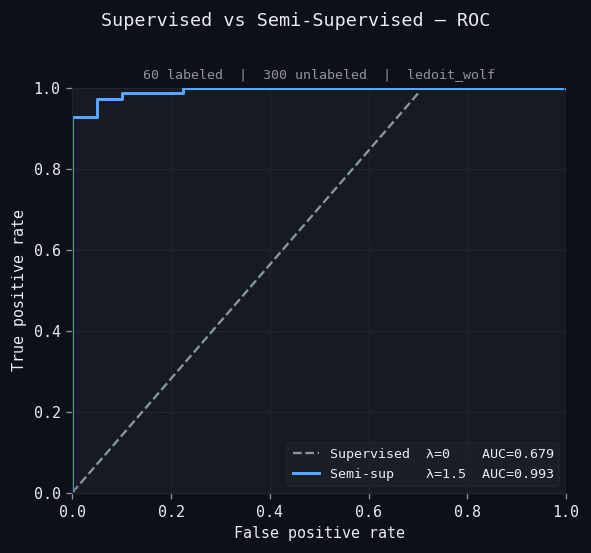

In [7]:
# ── ROC comparison: supervised vs. semi-supervised ────────────────────────────
fpr_semi, tpr_semi, _ = roc_curve(y_test, semi_fixed.predict_proba(X_test)[:, 1])

fig, ax = plt.subplots(figsize=(5, 4.5))
fig.suptitle("Supervised vs Semi-Supervised — ROC", y=1.01, fontsize=11)

ax.plot(fpr_sup,  tpr_sup,  color=GRAY,  lw=1.4, ls="--",
        label=f"Supervised  λ=0    AUC={auroc_sup:.3f}")
ax.plot(fpr_semi, tpr_semi, color=CYAN,  lw=1.8,
        label=f"Semi-sup    λ=1.5  AUC={auroc_semi:.3f}")
ax.plot([0, 1], [0, 1], color=GRID, lw=0.8, ls=":")

ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("60 labeled  |  300 unlabeled  |  ledoit_wolf", fontsize=8, color=GRAY)
ax.legend(fontsize=8, loc="lower right")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## 5. The λ path: how AUROC changes with unlabeled weight

Sweeping λ from near-zero to large reveals the **bias-variance tradeoff** introduced by unlabeled data.  
The validation curve exposes the optimal operating point before touching the test set.

In [8]:
lam_grid = np.logspace(-2, 2, 40)

val_aurocs  = []
test_aurocs = []

for lam in lam_grid:
    m = SemiSupervisedGMM(
        lambda_=lam, covariance_type="ledoit_wolf"
    ).fit(X_train_all, y_train)
    val_aurocs.append(m.score(X_val, y_val))
    test_aurocs.append(m.score(X_test, y_test))

best_idx = int(np.argmax(val_aurocs))
lam_star = lam_grid[best_idx]
print(f"Best validation λ* = {lam_star:.4f}")
print(f"Val  AUROC at λ*   = {val_aurocs[best_idx]:.4f}")
print(f"Test AUROC at λ*   = {test_aurocs[best_idx]:.4f}")

Best validation λ* = 1.4251
Val  AUROC at λ*   = 0.9799
Test AUROC at λ*   = 0.9935


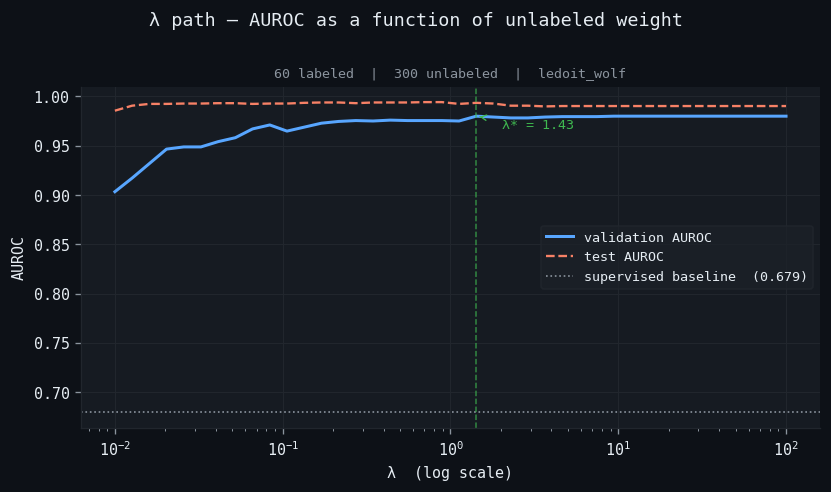

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
fig.suptitle("λ path — AUROC as a function of unlabeled weight", y=1.01, fontsize=11)

ax.plot(lam_grid, val_aurocs,  color=CYAN,   lw=1.8, label="validation AUROC")
ax.plot(lam_grid, test_aurocs, color=ORANGE, lw=1.4, ls="--", label="test AUROC")

ax.axhline(auroc_sup, color=GRAY, lw=1.0, ls=":", label=f"supervised baseline  ({auroc_sup:.3f})")
ax.axvline(lam_star, color=GREEN, lw=0.9, ls="--", alpha=0.7)
ax.annotate(
    f"  λ* = {lam_star:.2f}",
    xy=(lam_star, val_aurocs[best_idx]),
    xytext=(lam_star * 1.15, val_aurocs[best_idx] - 0.012),
    color=GREEN, fontsize=8,
    arrowprops=dict(arrowstyle="->", color=GREEN, lw=0.8),
)

ax.set_xscale("log")
ax.set_xlabel("λ  (log scale)")
ax.set_ylabel("AUROC")
ax.set_title("60 labeled  |  300 unlabeled  |  ledoit_wolf", fontsize=8, color=GRAY)
ax.legend(fontsize=8)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Grid-search λ selection (`fit_cv`)

`fit_cv` automates the sweep above: it fits one model per λ candidate and returns the model at the
validation-maximising λ.  The selected value is stored in `model.lambda_used_`.

In [10]:
semi_cv = SemiSupervisedGMM(covariance_type="ledoit_wolf").fit_cv(
    X_train_all, y_train,
    X_val, y_val,
    lam_grid=np.logspace(-2, 2, 25),
)

auroc_cv = semi_cv.score(X_test, y_test)
print(f"fit_cv selected  λ* = {semi_cv.lambda_used_:.4f}")
print(f"Test AUROC           = {auroc_cv:.4f}")

fit_cv selected  λ* = 2.1544
Test AUROC           = 0.9917


## 7. Gradient-learned λ (`LearnedLambdaGMM`)

`LearnedLambdaGMM` learns λ by gradient ascent on the validation log-likelihood using an
implicit-function-theorem (IFT) step at each iteration — no grid search required.
After fitting, `model.lambda_` holds the learned value.

In [11]:
ll_model = LearnedLambdaGMM(
    lambda_init=0.5,
    lr=0.5,
    n_steps=30,
    covariance_type="ledoit_wolf",
).fit(
    X_train_all, y_train,
    X_val=X_val, y_val=y_val,
)

auroc_ll = ll_model.score(X_test, y_test)
print(f"LearnedLambdaGMM  learned λ = {ll_model.lambda_:.4f}")
print(f"Test AUROC                   = {auroc_ll:.4f}")

LearnedLambdaGMM  learned λ = 1.5000
Test AUROC                   = 0.9931


## 8. Confidence-weighted local λ (`LocalLambdaGMM`)

`LocalLambdaGMM` assigns a per-point weight

$$\lambda(x) = \lambda \cdot \max\bigl(\gamma(x),\, 1 - \gamma(x)\bigr)^\alpha$$

where $\gamma(x)$ is the posterior class probability.  High-confidence unlabeled points (near
either class boundary) receive full weight; ambiguous points near the decision boundary are
down-weighted.  The `alpha` parameter controls the strength of the down-weighting.

In [12]:
local_model = LocalLambdaGMM(
    lambda_=semi_cv.lambda_used_,
    alpha=1.5,
    covariance_type="ledoit_wolf",
).fit(X_train_all, y_train)

auroc_loc = local_model.score(X_test, y_test)
print(f"LocalLambdaGMM  λ={semi_cv.lambda_used_:.3f}  α=1.5   AUROC = {auroc_loc:.4f}")

LocalLambdaGMM  λ=2.154  α=1.5   AUROC = 0.9938


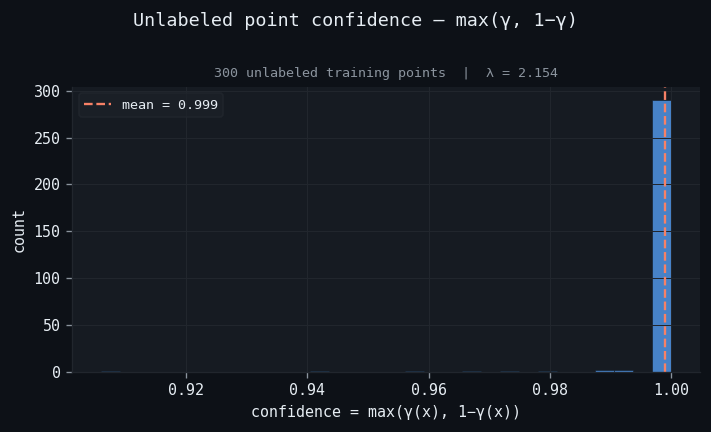

In [13]:
# ── posterior confidence distribution for unlabeled points ───────────────────
# Use the CV-selected model to compute γ(x) for unlabeled training examples
gamma_unl = semi_cv.predict_proba(X_train_all[N_LABELED:])[:, 1]
confidence = np.maximum(gamma_unl, 1 - gamma_unl)   # ∈ [0.5, 1]

fig, ax = plt.subplots(figsize=(6, 3.5))
fig.suptitle("Unlabeled point confidence — max(γ, 1−γ)", y=1.01, fontsize=11)

ax.hist(confidence, bins=30, color=CYAN, alpha=0.75, edgecolor=BG, linewidth=0.4)
ax.axvline(confidence.mean(), color=ORANGE, lw=1.4, ls="--",
           label=f"mean = {confidence.mean():.3f}")

ax.set_xlabel("confidence = max(γ(x), 1−γ(x))")
ax.set_ylabel("count")
ax.set_title("300 unlabeled training points  |  λ = {:.3f}".format(semi_cv.lambda_used_),
             fontsize=8, color=GRAY)
ax.legend(fontsize=8)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## 9. Estimator comparison summary

In [14]:
# ── collect all ROC curves ────────────────────────────────────────────────────
models_info = [
    ("SupervisedGMM  (λ=0)",      sup,         GRAY,   "--"),
    ("SemiSup        (λ=1.5)",    semi_fixed,  ORANGE, "-"),
    ("fit_cv         (λ=λ*)",     semi_cv,     CYAN,   "-"),
    ("LearnedLambda  (IFT)",      ll_model,    GREEN,  "-"),
    ("LocalLambda    (α=1.5)",    local_model, PURPLE, "-"),
]

aurocs = []
for label, model, color, ls in models_info:
    a = model.score(X_test, y_test)
    aurocs.append(a)
    print(f"{label:36s}  AUROC = {a:.4f}")

SupervisedGMM  (λ=0)                  AUROC = 0.6793
SemiSup        (λ=1.5)                AUROC = 0.9931
fit_cv         (λ=λ*)                 AUROC = 0.9917
LearnedLambda  (IFT)                  AUROC = 0.9931
LocalLambda    (α=1.5)                AUROC = 0.9938


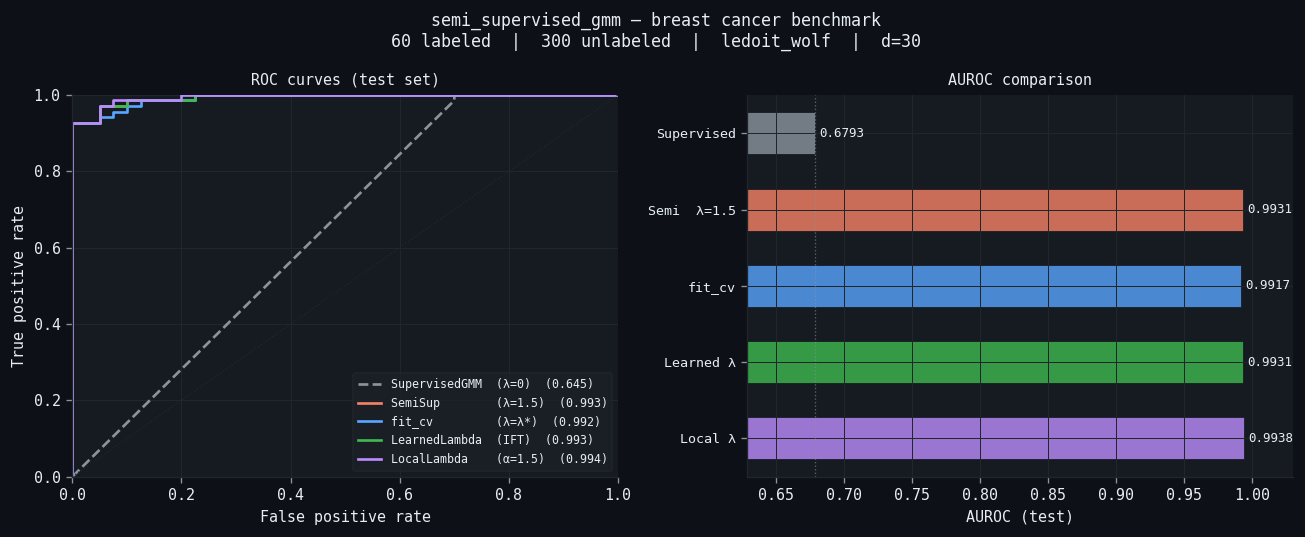

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle(
    "semi_supervised_gmm — breast cancer benchmark\n"
    "60 labeled  |  300 unlabeled  |  ledoit_wolf  |  d=30",
    fontsize=10,
)

# ── left panel: all ROC curves ────────────────────────────────────────────────
ax = axes[0]
for label, model, color, ls in models_info:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    a = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=1.6, ls=ls,
            label=f"{label}  ({a:.3f})")

ax.plot([0, 1], [0, 1], color=GRID, lw=0.8, ls=":")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves (test set)", fontsize=9)
ax.legend(fontsize=7, loc="lower right")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# ── right panel: AUROC bar chart ──────────────────────────────────────────────
ax2 = axes[1]
labels_short = [
    "Supervised",
    "Semi  λ=1.5",
    "fit_cv",
    "Learned λ",
    "Local λ",
]
colors = [m[2] for m in models_info]
y_pos  = np.arange(len(labels_short))

bars = ax2.barh(y_pos, aurocs, color=colors, alpha=0.80,
                edgecolor=BG, linewidth=0.5, height=0.55)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(labels_short, fontsize=8)
ax2.set_xlabel("AUROC (test)")
ax2.set_title("AUROC comparison", fontsize=9)

# value labels
x_min = min(aurocs) - 0.05
for bar, val in zip(bars, aurocs):
    ax2.text(
        val + 0.003, bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center", ha="left", fontsize=7.5, color=TEXT,
    )

ax2.set_xlim(x_min, 1.03)
ax2.axvline(auroc_sup, color=GRAY, lw=0.8, ls=":", alpha=0.6)
ax2.invert_yaxis()
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

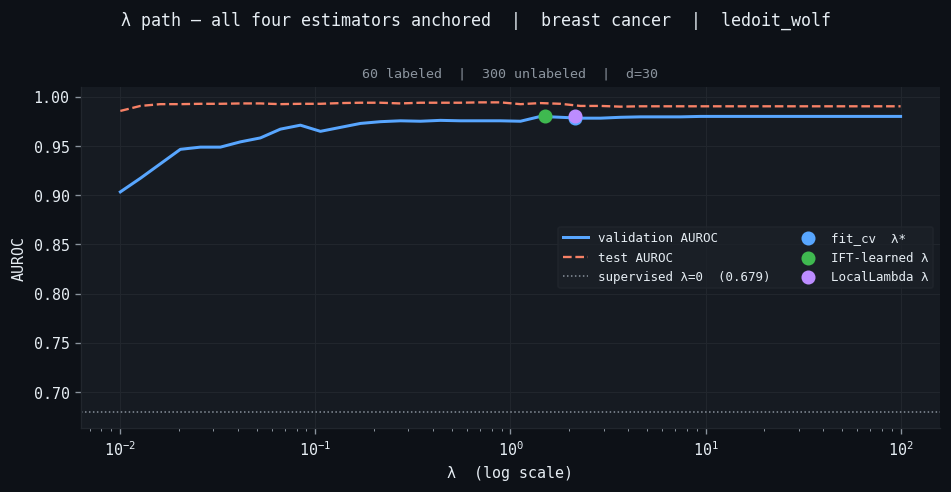

In [16]:
# ── λ path with both val + test curves, plus estimator anchors ────────────────
fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle(
    "λ path — all four estimators anchored  |  breast cancer  |  ledoit_wolf",
    y=1.01, fontsize=10,
)

ax.plot(lam_grid, val_aurocs,  color=CYAN,   lw=1.8, label="validation AUROC")
ax.plot(lam_grid, test_aurocs, color=ORANGE, lw=1.4, ls="--", label="test AUROC")
ax.axhline(auroc_sup, color=GRAY, lw=0.9, ls=":", label=f"supervised λ=0  ({auroc_sup:.3f})")

# anchor dots for each learned/selected estimator
anchors = [
    (semi_cv.lambda_used_,  semi_cv.score(X_val, y_val),  CYAN,   "fit_cv  λ*"),
    (ll_model.lambda_,      ll_model.score(X_val, y_val), GREEN,  "IFT-learned λ"),
    (local_model.lambda_,   local_model.score(X_val, y_val), PURPLE, "LocalLambda λ"),
]
for lam_pt, auc_pt, col, lbl in anchors:
    ax.scatter([lam_pt], [auc_pt], color=col, s=55, zorder=5, label=lbl)

ax.set_xscale("log")
ax.set_xlabel("λ  (log scale)")
ax.set_ylabel("AUROC")
ax.set_title("60 labeled  |  300 unlabeled  |  d=30", fontsize=8, color=GRAY)
ax.legend(fontsize=7.5, ncol=2)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()